<p align="center">
  <img src="https://raw.githubusercontent.com/Sanofi-Public/MIPHEI-ViT/main/MIPHEI_logo.svg" alt="MIPHEI-ViT Logo" style="height:250px;">
</p>

<p align="center">
  <a href="https://arxiv.org/abs/2505.10294" target="_blank" rel="noopener noreferrer" style="display: inline-block; vertical-align: middle;">
    <img src="https://img.shields.io/badge/arXiv-Paper-b31b1b?logo=arxiv&logoColor=white" height="25">
  </a>
  <a href="https://github.com/Sanofi-Public/MIPHEI-ViT" target="_blank" rel="noopener noreferrer" style="display: inline-block; vertical-align: middle;">
    <img src="https://img.shields.io/badge/GitHub-Code-black?logo=github" height="25">
  </a>
  <a href="https://huggingface.co/Estabousi/MIPHEI-vit" target="_blank" rel="noopener noreferrer" style="display: inline-block; vertical-align: middle;">
    <img src="https://img.shields.io/badge/HuggingFace-Model-yellow?logo=huggingface" height="25">
  </a>
  <a href="https://zenodo.org/records/15340874" target="_blank" rel="noopener noreferrer" style="display: inline-block; vertical-align: middle;">
    <img src="https://img.shields.io/badge/Zenodo-Dataset-blue?logo=zenodo" height="25">
  </a>
</p>

# ⚙️ Environment Setup

Please select a GPU T4 instance: **Runtime > Change runtime type > Hardware accelerator** to **GPU T4**

In [1]:
# Download Val and Test data from our preprocessed data of ORION-CRC
# Takes about 10 minutes

# You can replace this with other dataset download

!gdown --fuzzy https://drive.google.com/file/d/1Y4NO7kazlAAHDwuh0GJMR_NYSzuRMVOP/view?usp=drive_link
!7z x -mmt=on val_test_ORIONCRC_dataset_tile_20x.zip
!rm val_test_ORIONCRC_dataset_tile_20x.zip

Downloading...
From (original): https://drive.google.com/uc?id=1Y4NO7kazlAAHDwuh0GJMR_NYSzuRMVOP
From (redirected): https://drive.google.com/uc?id=1Y4NO7kazlAAHDwuh0GJMR_NYSzuRMVOP&confirm=t&uuid=b732060f-3593-4c3b-a15e-eeabe18846f7
To: /content/val_test_ORIONCRC_dataset_tile_20x.zip
100% 8.25G/8.25G [01:54<00:00, 72.1MB/s]

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 8248382402 bytes (7867 MiB)

Extracting archive: val_test_ORIONCRC_dataset_tile_20x.zip
  5% 4096 Open              --
Path = val_test_ORIONCRC_dataset_tile_20x.zip
Type = zip
Physical Size = 8248382402
64-bit = +

  0%      0% 2 - val_test_ORIONCRC_dataset_tile_2 . 20106_014319_409148-zlib.ome.csv

In [2]:
# Clone Hugging Face model

!git lfs install  # only needed once, if not already done
!git clone https://huggingface.co/Estabousi/MIPHEI-vit
%cd MIPHEI-vit
# Install dependencies for MIPHEI-VIT inference
!pip install -r requirements.txt -q

# Install CellPose for cell segmentation
!pip install cellpose==3.1.1.2 scikit-image scipy -q

Git LFS initialized.
Cloning into 'MIPHEI-vit'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 38 (delta 13), reused 0 (delta 0), pack-reused 5 (from 1)
Unpacking objects: 100% (38/38), 24.15 KiB | 2.42 MiB/s, done.
/content/MIPHEI-vit
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [8]:
import torch
from model import MIPHEIViT
from PIL import Image
import torchvision.transforms as T
from pathlib import Path
import numpy as np
import json

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [9]:
HE_DIR = "/content/val_test_ORIONCRC_dataset_tile_20x/he"  # Adapt if it is another dataset

# Run MIPHEI on Tiles

In [5]:
with open("config_hf.json", "r") as f:
  config = json.load(f)
channel_names = config["targ_channel_names"]
nc_out = len(channel_names)

width = height = config["img_size"]  # 256 but you can change to width, height power of 2 and at least 128

device = "cuda" if torch.cuda.is_available() else "cpu"
model = MIPHEIViT.from_pretrained_hf(repo_path=".")
model.set_input_size((width, height))
model = model.eval().to(device).half()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

In [ ]:
transform = T.Compose([
    T.Resize((width, height)),
    T.ToTensor(),  # Converts to shape [3, H, W], range [0,1]
    T.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),  # H-optimus-0 normalization
])


In [7]:
image_paths = [str(fn) for fn in Path(HE_DIR).glob("*.jpeg")]
len(image_paths)

23354

## Multiplex Immunofluorescence tile prediction

In [23]:
img = Image.open(image_paths[np.random.randint(len(image_paths))]).convert("RGB").crop((38, 38, 294, 294))
tile_tensor = transform(img).unsqueeze(0)  # Add batch dim: [1, 3, width, height]

# Predict mIF channels
with torch.inference_mode():
    mif_pred = model(tile_tensor.to(device).half()).squeeze()  # Output: [16, width, height]
    mif_pred = (mif_pred.clamp(-0.9, 0.9) + 0.9) / 1.8  # [-0.9, 0.9] -> [0., 1.]
    mif_pred = (mif_pred * 255).to(torch.uint8)
    mif_pred = mif_pred.permute((1, 2, 0)).cpu()

<ipython-input-24-4d209911c20f>:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


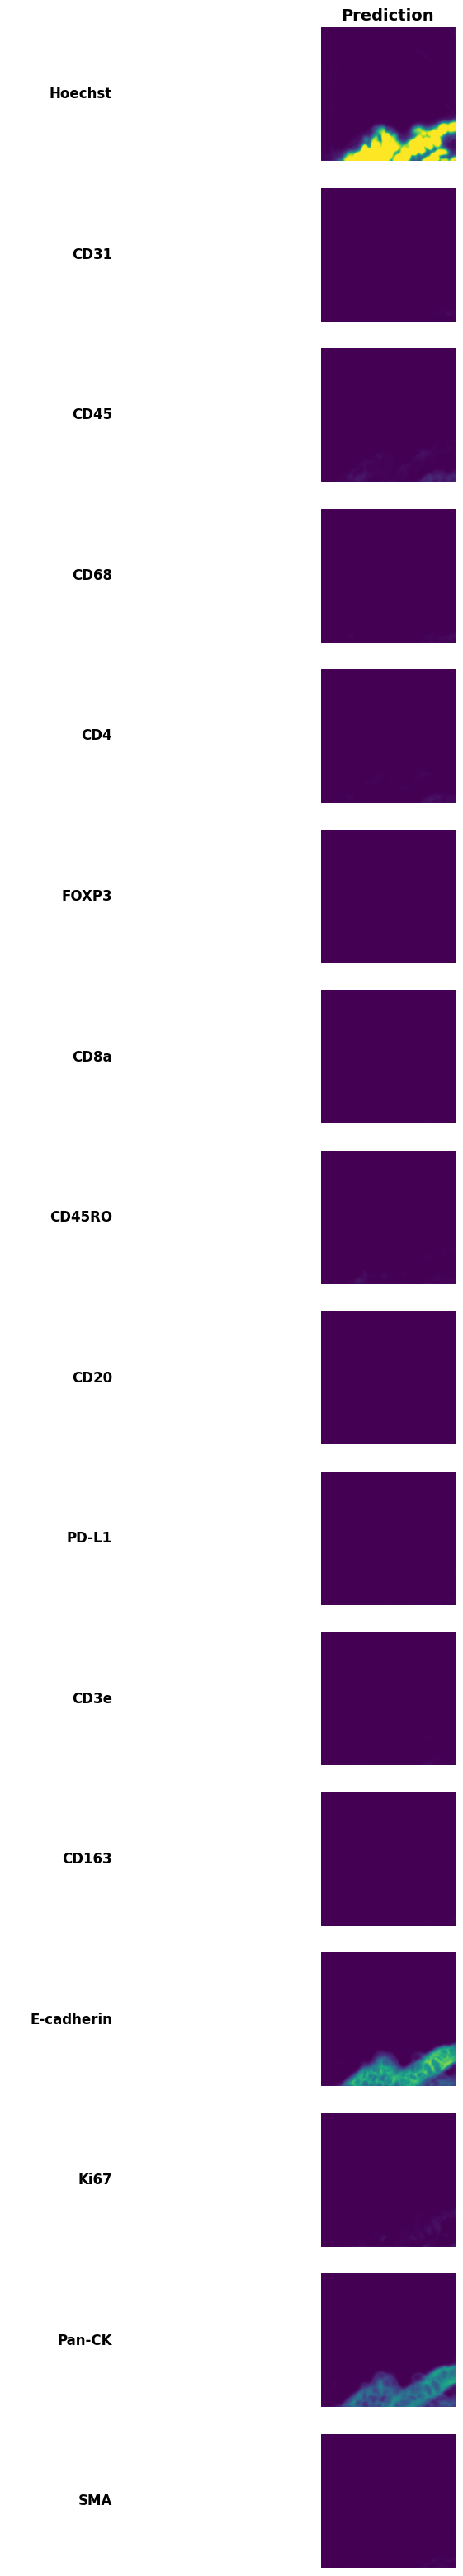

In [24]:
n_channels = len(channel_names)
fig = plt.figure(figsize=(10, 2.5 * n_channels))
gs = gridspec.GridSpec(n_channels, 2, width_ratios=[0.2, 1], wspace=0.05)

for i in range(n_channels):
    # Label column
    ax_label = fig.add_subplot(gs[i, 0])
    ax_label.axis("off")
    ax_label.text(1.0, 0.5, channel_names[i],
                  va='center', ha='right', fontsize=12, fontweight='bold')

    # Prediction
    ax_pred = fig.add_subplot(gs[i, 1])
    ax_pred.imshow(mif_pred[..., i], vmin=0, vmax=100, cmap='viridis')
    ax_pred.axis("off")
    if i == 0:
        ax_pred.set_title("Prediction", fontsize=14, fontweight="bold")


plt.tight_layout()
plt.show()

## Cell Type Prediction with MIPHEI and CellPose

In [12]:
#@title Cell Prediction Utils
#@markdown MeanCellExtrator allows to extract mean mIF intensities per images

import torch.nn as nn
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.morphology import binary_dilation, disk


class MeanCellExtrator(nn.Module):

    def forward(self, pred, nuclei):
        """
        Blabla

        Args:
            pred (torch.Tensor): Predicted tensor of shape [B, C, H, W].
            nuclei (torch.Tensor): Nuclei label tensor of shape [B, 1, H, W].

        Returns:
            torch.Tensor: L1 loss between extracted mean intensities.
        """
        # Downsample pred, target, and nuclei
        if nuclei.ndim == 3:
            nuclei = torch.unsqueeze(nuclei, dim=1).long()

        # Extract mean intensities for both pred and target
        pred_means, cell_ids = self.extract_mean(pred, nuclei)
        return pred_means, cell_ids

    def extract_mean(self, pred, nuclei):
        """
        Extract mean intensities for prediction using shared nuclei computations.

        Args:
            pred (torch.Tensor): Predicted tensor of shape [B, C, H, W].
            nuclei (torch.Tensor): Nuclei label tensor of shape [B, 1, H, W].

        Returns:
            torch.Tensor: Mean intensities for prediction, shape [num_labels, C].
            list[torch.Tensor]: Unique cell IDs for each batch element.
        """
        batch_size, num_channels, height, width = pred.shape

        # Prepare outputs
        all_pred_means = []
        all_cell_ids = []

        for b in range(batch_size):
            # Process each batch independently
            nuclei_b = nuclei[b, 0]  # Shape: [H, W]
            pred_b = pred[b]  # Shape: [C, H, W]

            # Create a binary mask for non-background pixels
            nuclei_binary = nuclei_b > 0

            # Apply the binary mask to nuclei
            nuclei_flat = nuclei_b[nuclei_binary]  # Shape: [num_valid_pixels]
            if nuclei_flat.numel() == 0:  # No valid regions
                all_pred_means.append(torch.zeros((0, num_channels), dtype=pred.dtype, device=pred.device))
                all_cell_ids.append(torch.empty(0, dtype=nuclei_b.dtype, device=nuclei_b.device))
                continue

            # Get unique labels and their indices
            unique_labels, inverse_indices = torch.unique(nuclei_flat, return_inverse=True)

            # Apply the mask to pred and target, flatten and preserve the channel dimension
            pred_flat = pred_b.permute(1, 2, 0)[nuclei_binary]  # Shape: [num_valid_pixels, C]

            # Compute sums per region and channel for pred and target
            pred_sums = torch.zeros((unique_labels.shape[0], num_channels), dtype=pred.dtype, device=pred.device).scatter_add_(
                0, inverse_indices.unsqueeze(1).expand(-1, num_channels), pred_flat
            )

            # Compute counts per region
            region_counts = torch.zeros(unique_labels.shape[0], dtype=torch.float32, device=nuclei.device).scatter_add_(
                0, inverse_indices, torch.ones_like(nuclei_flat, dtype=torch.float32)
            )

            # Compute mean intensities
            pred_means = pred_sums / region_counts.unsqueeze(1)

            # Append results
            all_pred_means.append(pred_means)
            all_cell_ids.append(unique_labels)

        # Concatenate results across batches
        pred_means = torch.cat(all_pred_means, dim=0)
        cell_ids = torch.cat(all_cell_ids, dim=0)

        return pred_means.to(pred.dtype), cell_ids


def inference_cellpose(x, cellpose_model, radius=None):
    nuclei_mask, _, _, _ = cellpose_model.eval(
            x,
            channels=[0, 0],
            diameter=None,
            min_size=15,
            normalize=True,
            invert=True,
            flow_threshold=0.4,
    )

    if radius is not None:
        # watershed nuclei expansion
        binary = nuclei_mask > 0
        dilated_mask = binary_dilation(binary, footprint=disk(radius))
        distance = ndi.distance_transform_edt(~binary)
        nuclei_mask = watershed(-distance, markers=nuclei_mask, mask=dilated_mask, watershed_line=False)
    return nuclei_mask


def create_nuclei_types(nuclei_mask_torch, cell_predictions, cell_ids):
    height, width = nuclei_mask_torch.shape[2], nuclei_mask_torch.shape[3]
    nuclei_types_torch = torch.zeros((1, 15, height, width), dtype=torch.bool)

    for idx_class in range(15):
        cell_ids_class = cell_ids[cell_predictions[..., idx_class]]
        nuclei_types_torch[:, idx_class] = torch.isin(nuclei_mask_torch, cell_ids_class).cpu()
    return nuclei_types_torch

In [13]:
from cellpose import models

cellpose_model = models.Cellpose(model_type="nuclei", gpu=device == "cuda")
mean_extractor = MeanCellExtrator().to(device)
n_marker = nc_out - 1
logreg = torch.nn.Linear(15, n_marker)
logreg_state_dict = torch.load("logreg.pth", map_location="cpu")
logreg.load_state_dict(logreg_state_dict)
logreg.eval().to(device)

100%|██████████| 25.3M/25.3M [00:00<00:00, 31.5MB/s]
100%|██████████| 3.54k/3.54k [00:00<00:00, 6.05MB/s]


Linear(in_features=15, out_features=15, bias=True)

In [14]:
image = Image.open(image_paths[np.random.randint(len(image_paths))]).convert("RGB").crop((38, 38, 294, 294))
input_tensor = transform(image).unsqueeze(0)  # Add batch dim: [1, 3, width, height]

with torch.inference_mode():
    instance_mask = inference_cellpose(np.asarray(image), cellpose_model, radius=None)
    instance_mask_torch = torch.from_numpy(instance_mask).unsqueeze(0).unsqueeze(0).to(device).long()
    output_mif = model(input_tensor.to(device).half())
    output_mif = output_mif.clamp(-0.9, 0.9)
    pred_cell_means, cell_ids = mean_extractor(output_mif.float(), instance_mask_torch)
    pred_cell_means = (pred_cell_means + 0.9) / 1.8 * 255
    cell_predictions = torch.sigmoid(logreg(pred_cell_means[..., 1:])) > 0.5
    output_celltypes = create_nuclei_types(instance_mask_torch, cell_predictions, cell_ids)[0].cpu().numpy()
    cell_ids = cell_ids.cpu()
    instance_mask_torch = instance_mask_torch.cpu()

    output_mif = (output_mif[0] + 0.9) / 1.8 * 255
    output_mif = np.uint8(output_mif.cpu().numpy())

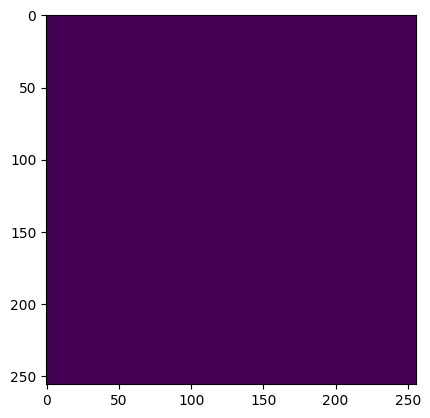

In [15]:
plt.imshow(output_celltypes[0])

# WSI Inference

In [ ]:
%cd ../
!git clone https://github.com/Sanofi-Public/MIPHEI-ViT.git
%cd MIPHEI-ViT
!pip install -r requirements.txt
!apt-get install -y libvips-dev -qq
!pip install pyvips -q
!pip install -e slidevips-python -q

In [ ]:
# We download one CRC WSI from TCGA

!wget https://gdc.cancer.gov/system/files/public/file/gdc-client_2.3_Ubuntu_x64-py3.8-ubuntu-20.04.zip
!unzip gdc-client_2.3_Ubuntu_x64-py3.8-ubuntu-20.04.zip
!unzip gdc-client_2.3_Ubuntu_x64.zip
!chmod +x gdc-client
!./gdc-client download 1e1d8d98-9965-4c8d-92dd-c88cfc6cce2c
!rm gdc-client*
!mv 1e1d8d98-9965-4c8d-92dd-c88cfc6cce2c/TCGA-G4-6298-01Z-00-DX1.83055d52-71f7-46ec-be53-11d86b19b4cf.svs ../
!rm -r 1e1d8d98-9965-4c8d-92dd-c88cfc6cce2c/

In [ ]:
!mkdir /content/wsi_predictions/
!python run_wsi_inference.py --slide_path /content/TCGA-G4-6298-01Z-00-DX1.83055d52-71f7-46ec-be53-11d86b19b4cf.svs  --checkpoint_dir /content/MIPHEI-vit/ --output_dir /content/wsi_predictions/

# Evaluation

## ORION Evaluation

You need to have downloaded Val + Test ORION-CRC tile dataset

In [107]:
# We run this to set the correct paths

from omegaconf import OmegaConf
import pandas as pd

# Link correct path in Orion data config
cfg = OmegaConf.load("configs/data/orion.yaml")
cfg.data.slide_dataframe_path = "/content/val_test_ORIONCRC_dataset_tile_20x/slide_dataframe.csv"
cfg.data.train_dataframe_path = None
cfg.data.val_dataframe_path = "/content/val_test_ORIONCRC_dataset_tile_20x/val_dataframe.csv"
cfg.data.test_dataframe_path = "/content/val_test_ORIONCRC_dataset_tile_20x/test_dataframe.csv"
OmegaConf.save(cfg, "configs/data/orion.yaml")

# Link correct path for csvs containing nuclei subtypes
slide_dataframe = pd.read_csv("/content/val_test_ORIONCRC_dataset_tile_20x/slide_dataframe.csv")
if not slide_dataframe["nuclei_csv_path"].apply(lambda x: Path(x).exists()).any():  # avoid error if we run the cell multiple times
  slide_dataframe["nuclei_csv_path"] = slide_dataframe["nuclei_csv_path"].apply(lambda x: str(Path("/content/val_test_ORIONCRC_dataset_tile_20x") / x))
  slide_dataframe.to_csv("/content/val_test_ORIONCRC_dataset_tile_20x/slide_dataframe.csv", index=False)

# Link correct path for image, target and nuclei masks on Validation set
val_dataframe = pd.read_csv("/content/val_test_ORIONCRC_dataset_tile_20x/val_dataframe.csv")
if not Path(val_dataframe["image_path"].iloc[0]).exists():  # avoid error if we run the cell multiple times
  val_dataframe["image_path"] = val_dataframe["image_path"].apply(lambda x: str(Path("/content/val_test_ORIONCRC_dataset_tile_20x") / x))
  val_dataframe["target_path"] = val_dataframe["target_path"].apply(lambda x: str(Path("/content/val_test_ORIONCRC_dataset_tile_20x") / x))
  val_dataframe["nuclei_path"] = val_dataframe["nuclei_path"].apply(lambda x: str(Path("/content/val_test_ORIONCRC_dataset_tile_20x") / x))
  val_dataframe.to_csv("/content/val_test_ORIONCRC_dataset_tile_20x/val_dataframe.csv", index=False)

# Link correct path for image, target and nuclei masks on Test set
test_dataframe = pd.read_csv("/content/val_test_ORIONCRC_dataset_tile_20x/test_dataframe.csv")
if not Path(test_dataframe["image_path"].iloc[0]).exists():  # avoid error if we run the cell multiple times
  test_dataframe["image_path"] = test_dataframe["image_path"].apply(lambda x: str(Path("/content/val_test_ORIONCRC_dataset_tile_20x") / x))
  test_dataframe["target_path"] = test_dataframe["target_path"].apply(lambda x: str(Path("/content/val_test_ORIONCRC_dataset_tile_20x") / x))
  test_dataframe["nuclei_path"] = test_dataframe["nuclei_path"].apply(lambda x: str(Path("/content/val_test_ORIONCRC_dataset_tile_20x") / x))


In [108]:
# Takes about 30 minutes in Colab
%cd evaluation
!python eval_orion.py --checkpoint_dir /content/MIPHEI-vit/
%cd ../

/content/MIPHEI-ViT/evaluation
/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.7' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
256 width / 256 height
3 inputs channels / 16 output channels
he [[180.341865 147.575895 179.422335]] [[54.030165 58.679835 45.266835]]
Loading checkpoint from safetensors
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100% 5839/5839 [29:1

In [110]:
pd.read_csv("/content/MIPHEI-vit/results_logreg.csv")

,Marker,ROC AUC,Balanced Accuracy,F1 Score
0,CD31_pos,0.887493,0.770851,0.373325
1,CD45_pos,0.898113,0.797775,0.677349
2,CD68_pos,0.851506,0.756759,0.355252
3,CD4_pos,0.894681,0.799347,0.550030
4,FOXP3_pos,0.871864,0.779587,0.109479
5,CD8a_pos,0.882658,0.781925,0.220742
6,CD45RO_pos,0.920990,0.826618,0.450494
7,CD20_pos,0.912720,0.786642,0.296280
8,PD-L1_pos,0.666710,0.602484,0.042230
9,CD3e_pos,0.902206,0.805827,0.558983


## HEMIT Evaluation

In [ ]:
# aria2 for fast download
!apt-get install -y aria2 -qq

# Download original HEMIT dataset from https://data.mendeley.com/datasets/3gx53zm49d/1
!aria2c -x 16 -s 16 https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/3gx53zm49d-1.zip
!7z x 'HEMIT H&E to Multiplex-immunohistochemistry Image Translation with Dual-Branch Pix2pix Generator.zip' -o/content
!rm 'HEMIT H&E to Multiplex-immunohistochemistry Image Translation with Dual-Branch Pix2pix Generator.zip'
!mkdir /content/HEMIT_dataset
!7z x /content/'HEMIT H&E to Multiplex-immunohistochemistry Image Translation with Dual-Branch Pix2pix Generator'/HEMIT.7z -o/content/HEMIT_dataset
!rm -r /content/'HEMIT H&E to Multiplex-immunohistochemistry Image Translation with Dual-Branch Pix2pix Generator'

# Donwload the nuclei mask and cell types we extracted https://zenodo.org/records/15340874
!aria2c -x 16 -s 16 https://zenodo.org/records/15340874/files/HEMIT_nuclei_analysis.zip?download=1
!7z x HEMIT_nuclei_analysis.zip -o/content
!rm HEMIT_nuclei_analysis.zip

!mv /content/HEMIT_nuclei_analysis/train/* /content/HEMIT_dataset/train
!mv -r /content/HEMIT_nuclei_analysis/val/* /content/HEMIT_dataset/val
!mv -r /content/HEMIT_nuclei_analysis/test/* /content/HEMIT_dataset/test
!rm -r /content/HEMIT_nuclei_analysis/

In [191]:
slide_dataframe = pd.DataFrame(columns=["in_slide_name", "nuclei_csv_path"])
slide_dataframe["nuclei_csv_path"] = [str(fn) for fn in Path("/content/HEMIT_dataset/").rglob("*.csv")]
slide_dataframe["in_slide_name"] = slide_dataframe["nuclei_csv_path"].apply(lambda x: Path(x).stem)

train_dataframe = pd.DataFrame(columns=["in_slide_name", "image_path", "target_path", "nuclei_path"])
train_dataframe["image_path"] = [str(fn) for fn in Path("/content/HEMIT_dataset/train/input").glob("*.tif")]
train_dataframe["target_path"] = train_dataframe["image_path"].apply(lambda x: x.replace("/input/", "/label/"))
train_dataframe["nuclei_path"] = train_dataframe["image_path"].apply(lambda x: x.replace("/input/", "/mask/"))
train_dataframe["in_slide_name"] = train_dataframe["image_path"].apply(lambda x: Path(x).stem)

val_dataframe = pd.DataFrame(columns=["in_slide_name", "image_path", "target_path", "nuclei_path"])
val_dataframe["image_path"] = [str(fn) for fn in Path("/content/HEMIT_dataset/val/input").glob("*.tif")]
val_dataframe["target_path"] = val_dataframe["image_path"].apply(lambda x: x.replace("/input/", "/label/"))
val_dataframe["nuclei_path"] = val_dataframe["image_path"].apply(lambda x: x.replace("/input/", "/mask/"))
val_dataframe["in_slide_name"] = val_dataframe["image_path"].apply(lambda x: Path(x).stem)


test_dataframe = pd.DataFrame(columns=["in_slide_name", "image_path", "target_path", "nuclei_path"])
test_dataframe["image_path"] = [str(fn) for fn in Path("/content/HEMIT_dataset/test/input").glob("*.tif")]
test_dataframe["target_path"] = test_dataframe["image_path"].apply(lambda x: x.replace("/input/", "/label/"))
test_dataframe["nuclei_path"] = test_dataframe["image_path"].apply(lambda x: x.replace("/input/", "/mask/"))
test_dataframe["in_slide_name"] = test_dataframe["image_path"].apply(lambda x: Path(x).stem)

slide_dataframe.to_csv("/content/HEMIT_dataset/slide_dataframe.csv", index=False)
train_dataframe.to_csv("/content/HEMIT_dataset/train_dataframe.csv", index=False)
val_dataframe.to_csv("/content/HEMIT_dataset/val_dataframe.csv", index=False)
test_dataframe.to_csv("/content/HEMIT_dataset/test_dataframe.csv", index=False)

print(len(train_dataframe), len(val_dataframe), len(test_dataframe))


3717 630 945


In [192]:
# We run this to set the correct paths

from omegaconf import OmegaConf
import pandas as pd

# Link correct path in Orion data config
cfg = OmegaConf.load("configs/data/hemit.yaml")
cfg.data.slide_dataframe_path = "/content/HEMIT_dataset/slide_dataframe.csv"
cfg.data.train_dataframe_path = "/content/HEMIT_dataset/train_dataframe.csv"
cfg.data.val_dataframe_path = "/content/HEMIT_dataset/val_dataframe.csv"
cfg.data.test_dataframe_path = "/content/HEMIT_dataset/test_dataframe.csv"
OmegaConf.save(cfg, "configs/data/hemit.yaml")


In [193]:
# Takes about 30 minutes in Colab
%cd evaluation
!python eval_hemit.py --checkpoint_dir /content/MIPHEI-vit/
%cd ../

/content/MIPHEI-ViT/evaluation
/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.7' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
1024 width / 1024 height
3 inputs channels / 16 output channels
he [[180.341865 147.575895 179.422335]] [[54.030165 58.679835 45.266835]]
Loading checkpoint from safetensors
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100% 1323/1323 [28

In [ ]:
pd.read_csv("/content/MIPHEI-vit/hemit_results_logreg.csv")